In [489]:
import importlib
import time
import sys
import numpy as np
import matplotlib.pyplot as plt
from PredictorEventBased import Predictor, spike_signal
from SpikingSystems import IFSpikeEncoder_absolute, SpringMassDamper
from Plots import compare_event_time_predictions, plot_gains_event_based, plot_raw_predictions_event_based, plot_prediction_error_event_based
importlib.reload(sys.modules['PredictorEventBased'])
importlib.reload(sys.modules['SpikingSystems'])
from PredictorEventBased import Predictor, spike_signal
from SpikingSystems import IFSpikeEncoder_absolute, SpringMassDamper



In [490]:
# 1) Set up system:
# Simulation parameters
dt = 0.01
# Create spring-mass-damper system
mass = 1.0
damping = 1.0
stiffness = 1.0
system = SpringMassDamper(dt, mass, damping, stiffness)
# Set up the spike-encoder
encoder = IFSpikeEncoder_absolute(dt=dt, threshold=0.05)

# 2) Set up predictor:
predictor = Predictor(
    n_inputs=encoder.n_outputs,   # Number of input channels
    gamma_weights=0.99,   # Decay factor for covariance estimates
    tau_decay=0.2,      # Time constant for trace decay
    lambda_ridge=1e-3,   # Ridge regularization parameter
    eta=0.05,            # Learning rate for gradient update
    cumulative_channels=[], # Always accumulate covariance for first input channel
    reference_tracking_costs=[0.0, 0.1], # Cost for tracking reference in each output channel (0 means no reference tracking)
    sigmoid_enable=True,
    affine=True,   # Include affine term in predictor
    spiking=True
)



ValueError: x and y must be the same size

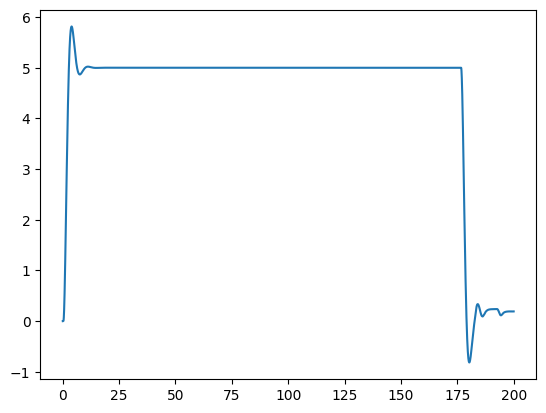

In [491]:
# Test simulation:
T = 200.0
time = np.arange(0, T, dt)
x = [system.y.item()] # Position
t_spikes_x = [] # Spike times for output
t_spikes_u = [] # Spike times for input
predictions = [] # Predictions 

next_spike_time = - predictor.tau_decay * np.log(np.clip(predictor.spike_threshold, 1e-3, 1-1e-3)) # Initialize next spike time based on predictor parameters
reference = np.zeros(predictor.n_outputs) # Reference signal for predictor (not used in this example)
reference[1] = 1.
for k, t in enumerate(time):
    # Get controller input
    if t >= next_spike_time:
        u_in = 5.0
        t_spikes_u.append(t)
    else:
        u_in = 0
    system.step(u_in, dt) # Step system with input
    x.append(system.y.item())
    spike = encoder.step(system.y.item())
    if spike[0] == 1:
        t_spikes_x.append(t)
        pred, _ = predictor.gradient_update(t, spike, reference) # Update predictor with spike event
        predictions.append(pred)
        next_spike_time = t - predictor.tau_decay * np.log(np.clip(predictor.spike_threshold, 1e-3, 1-1e-3)) # Update next spike time based on current time
    elif u_in != 0:
        pred, _ = predictor.gradient_update(t, spike, reference) # Update predictor
        predictions.append(pred)
        next_spike_time = t - predictor.tau_decay * np.log(np.clip(predictor.spike_threshold, 1e-3, 1-1e-3)) # Update next spike time based on current time

# # Plot
plt.plot(np.arange(len(x)) * dt, x)
plt.scatter(t_spikes_x, [x[i] for i in range(len(x)) if i in [int(t/dt) for t in t_spikes_x]], color='red', label='Spikes')
plt.xlabel("Time [s]")
plt.ylabel("Displacement")
plt.legend()
plt.show()

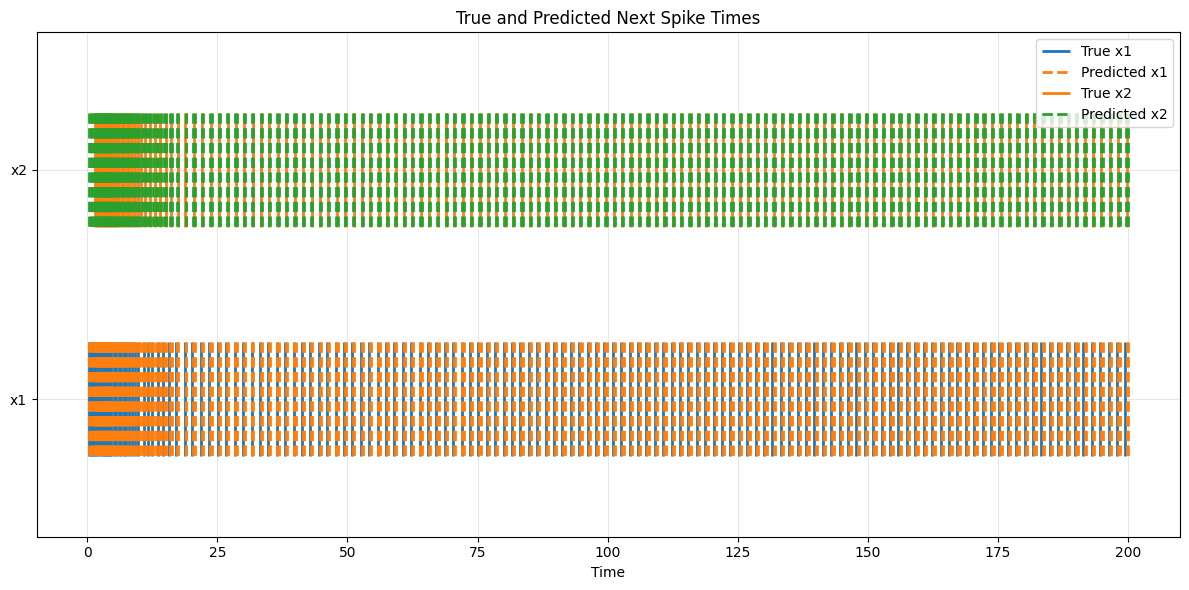

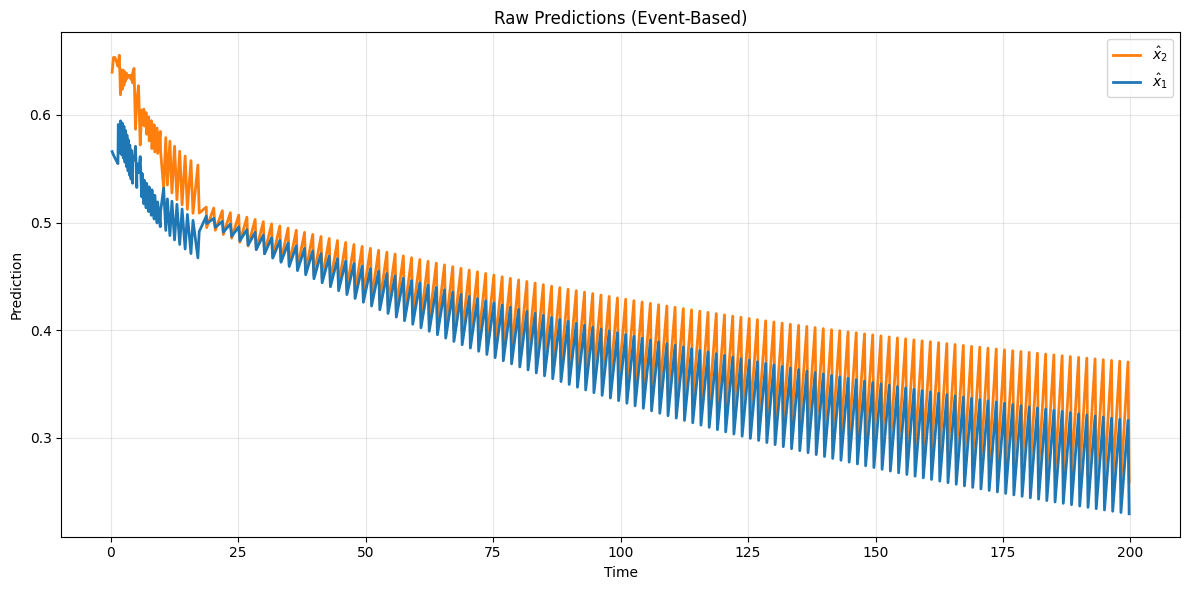

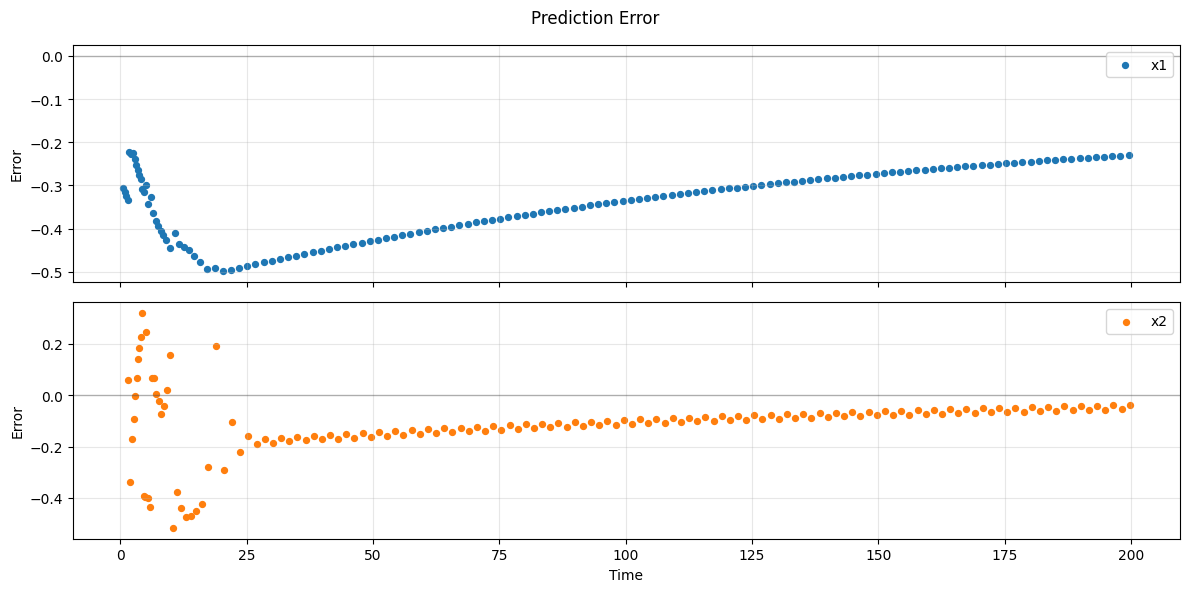

(<Figure size 1200x600 with 2 Axes>,
 array([<Axes: ylabel='Error'>, <Axes: xlabel='Time', ylabel='Error'>],
       dtype=object),
 array([[-0.30668148, -0.31610445, -0.32546146, -0.33426429,         nan,
         -0.22322416,         nan, -0.22661143,         nan, -0.22464555,
                 nan, -0.23952779,         nan, -0.25276182,         nan,
         -0.2647324 ,         nan, -0.27558205,         nan, -0.28560339,
                 nan, -0.30807627,         nan, -0.31494243,         nan,
         -0.29835512,         nan, -0.34240074,         nan, -0.32675668,
                 nan, -0.36302284,         nan, -0.38224291,         nan,
         -0.39425111,         nan, -0.40439741,         nan, -0.41395681,
                 nan, -0.4251522 ,         nan, -0.44492875,         nan,
                 nan, -0.40955238,         nan, -0.43571392,         nan,
         -0.44179614,         nan, -0.44979961,         nan, -0.46283019,
                 nan, -0.47736519,         nan, -0.4938

In [ ]:
all_spike_times = sorted(set(t_spikes_x).union(t_spikes_u))
event_times = [t_spikes_u, t_spikes_x]
predictions = np.array(predictions).T
compare_event_time_predictions(
    event_times=all_spike_times,
    x_event_times=event_times,
    predictions=predictions,
    tau=predictor.tau_decay,
)

# plot_gains_event_based(
#     event_times=all_spike_times,
#     prediction_gains=PredictionGains,
# )

# Plot raw predictions:
plot_raw_predictions_event_based(
    event_times=all_spike_times,
    predictions=predictions,
)

# Plot one-step-ahead prediction error:
plot_prediction_error_event_based(
    event_times=all_spike_times,
    x_event_times=event_times,
    predictions=predictions,
    tau=predictor.tau_decay,
)
